This part has two problems:
1. Determination of the value of alpha required to match the given problem.
2. After alpha is determined, find the min number of grid points required to implement the solution successfully.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

# Constants
Z = 54 # Atomic number for Xenon
alpha = 2.0 # Screen parameter to adjust

# Imaginary time step (Δτ)
delta = -0.9
E_k = -0.446
Delta_tau = 2*delta/E_k
imagDeltaTau = (-1j*Delta_tau)

Delta_r = 0.004 # Grid spacing a.u. # (Å)
N = 5000 # Number of grid points
r_vec = np.linspace(Delta_r, N * Delta_r, N) # Grid
ell = 1

desiredNodes = 5 - ell - 1

# involves tuning the screening parameter to fit the true energy value (E = -0.466, specified above) of the Xe atom (5p electon) 
maxBisectionIter = 50
alpha_lower = 2
alpha_upper = 3

In [2]:
""" new fn: count the number of nodes in the implementation"""
def count_nodes(psi):
    return np.sum(np.abs(np.diff(np.sign(psi))) / 2)

# creates the matrices necessary for CN
def create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, deltaTau):
    Delta_r = r_vec[1] - r_vec[0]
    N = len(r_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_r**2)
    D_11_corr = -2*(1 - (Z*Delta_r)/(12 - 10*Z*Delta_r))/(Delta_r**2)
    if ell == 0:
        D_diag[0] = D_11_corr
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
    if ell == 0:
        M_2_diag[0] = -2*(1 + (Delta_r**2)*D_11_corr/12)
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

# Crank-Nicolson propagation
def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

# Compute energy (expectation value of Hamiltonian)
def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

# general scalar projection function
def project(psi1, psi2, r_vec):
    return np.trapz(np.conj(psi1)*psi2, x=r_vec)
def normalize(psi, r_vec):
    return psi/np.sqrt(project(psi, psi, r_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

In [3]:
# bisection loop to tune the alpha value until the actual value of energy is achieved
for iter in range(maxBisectionIter):
    alpha = (alpha_lower + alpha_upper) / 2
    print(iter, alpha)

    
    
    # Modify the potential for Xenon, for current value of alpha
    V_coul = -1/r_vec - (Z - 1) / r_vec * np.exp(-alpha * r_vec)
    V_vec = V_coul + ell*(ell+1)/(2*r_vec**2) # V_eff contains both Coulomb and Centrifugal potentials 
    
    # Create matrices
    A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, imagDeltaTau)
    
    # Initial wavefunction (guessed)
    psi = np.random.random(N).astype(complex) # np.zeros(N)
    psi = normalize(psi, r_vec)
    
    # Crank-Nicolson propagation
    psi = CN_propagation(A_pl, A_mi, psi, r_vec, N_iter=1000)
    E = calc_E_withNumerov(psi, H_2, M_2, r_vec)
    noNodes = count_nodes(psi)
    
    # tuning the alpha for next iteration, based on the number of nodes
    if noNodes > desiredNodes:
        alpha_lower = alpha
    elif noNodes < desiredNodes:
        alpha_upper = alpha
    else:
        if np.abs(E - E_k) < 1e-5:
            break
        elif E < E_k:
            alpha_lower = alpha
        else:
            alpha_upper = alpha
            


0 2.5
1 2.75
2 2.625
3 2.5625
4 2.53125
5 2.515625
6 2.5234375
7 2.51953125
8 2.517578125
9 2.5185546875
10 2.51904296875
11 2.518798828125
12 2.5189208984375
13 2.51885986328125
14 2.518890380859375


/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, '5P wavefunc of Xe-atom, Screening Parameter=2.518890380859375')

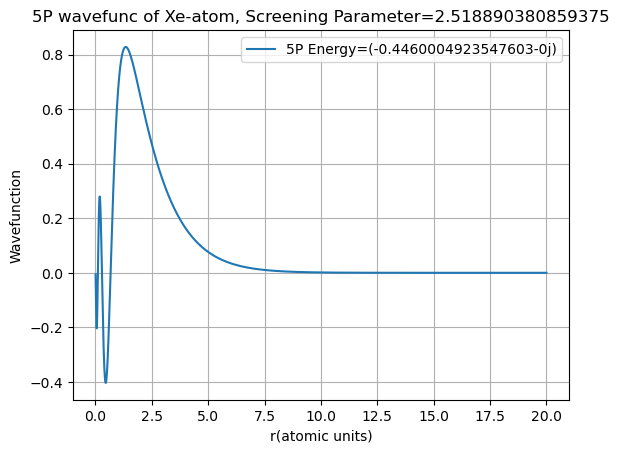

In [4]:
plt.plot(r_vec, psi, label=f"5P Energy={E}")
plt.xlabel("r(atomic units)")
plt.grid()
plt.ylabel("Wavefunction")
plt.legend()
plt.title(f"5P wavefunc of Xe-atom, Screening Parameter={alpha}")